# Breakout Fantasy Player Prediction â€” 2025

Identify players who significantly outperformed pre-season expectations.

**Approach:**
1. Define two breakout tiers: *first-time* (never been elite) vs *bounce-back* (was elite, fell out, returned)
2. Analyze what end-of-prior-season signals distinguish breakout players
3. Train a GBM classifier on 2021â€“2023 historical patterns
4. Validate on 2024; predict 2025 breakout candidates from end-of-2024 data
5. Score predictions against actual 2025 results

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score
from matplotlib.patches import Patch

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 130)


df = pd.read_csv('features_dataset.csv')
print(f'features_dataset: {df.shape[0]:,} rows x {df.shape[1]} cols')
print(f'Seasons: {sorted(df["season"].unique())}')
print(f'Positions: {list(df["position"].unique())}')

features_dataset: 30,213 rows x 92 cols
Seasons: [2020, 2021, 2022, 2023, 2024, 2025]
Positions: ['QB', 'TE', 'WR', 'RB']


## 1. Breakout Definitions

**Top-tier thresholds (half-PPR season totals):**

| Position | Elite Threshold |
|----------|-----------------|
| QB | Top 12 |
| RB | Top 24 |
| WR | Top 36 |
| TE | Top 12 |

**Breakout types:**
- **First-time breakout**: player has *never* finished in the top tier in prior seasons â€” genuine emergence
- **Bounce-back breakout**: was previously elite, fell out due to injury/down year, returned to elite

The model targets *any* breakout (outside top tier last year â†’ inside top tier this year), but we separately label first-time vs bounce-back for analysis.

In [2]:
THRESHOLDS = {'QB': 12, 'RB': 24, 'WR': 36, 'TE': 12}

season_totals = (
    df.groupby(['player_id', 'player_display_name', 'position', 'season'])['target_half_ppr']
    .sum().reset_index().rename(columns={'target_half_ppr': 'season_pts'})
)
season_totals['pos_rank'] = (
    season_totals.groupby(['position', 'season'])['season_pts']
    .rank(ascending=False, method='min').astype(int)
)

# --- Prior-season rank -------------------------------------------------------
prev = season_totals[['player_id', 'season', 'pos_rank', 'season_pts']].copy()
prev['season'] = prev['season'] + 1
prev = prev.rename(columns={'pos_rank': 'prev_rank', 'season_pts': 'prev_pts'})
season_totals = season_totals.merge(prev, on=['player_id', 'season'], how='left')

# --- Best-ever rank before this season (was player ever elite before?) -------
def add_best_prior_rank(df_in):
    rows = []
    for pid, grp in df_in.sort_values('season').groupby('player_id'):
        best = np.inf
        for _, row in grp.iterrows():
            rows.append({'player_id': pid, 'season': row['season'], 'best_prev_rank': best})
            if row['pos_rank'] < best:
                best = row['pos_rank']
    return pd.DataFrame(rows)

best_prior = add_best_prior_rank(season_totals)
season_totals = season_totals.merge(best_prior, on=['player_id', 'season'], how='left')

# --- Breakout labels ---------------------------------------------------------
def label_breakout(row):
    thresh = THRESHOLDS.get(row['position'], 24)
    if row['pos_rank'] > thresh or pd.isna(row['prev_rank']):
        return 'none'
    if row['prev_rank'] <= thresh:
        return 'none'  # already elite last year
    was_ever_elite = row['best_prev_rank'] <= thresh
    return 'bounce_back' if was_ever_elite else 'first_time'

season_totals['breakout_type'] = season_totals.apply(label_breakout, axis=1)
season_totals['breakout'] = season_totals['breakout_type'] != 'none'

print('Breakout breakdown by type and season:')
print(season_totals[season_totals['breakout']]
      .groupby(['season', 'breakout_type']).size().unstack(fill_value=0))
print()
print('Total breakouts:', season_totals['breakout'].sum(),
      f'  | first-time: {(season_totals["breakout_type"]=="first_time").sum()}',
      f'  | bounce-back: {(season_totals["breakout_type"]=="bounce_back").sum()}')

Breakout breakdown by type and season:
breakout_type  bounce_back  first_time
season                                
2021                     0          28
2022                     3          23
2023                     9          17
2024                    12          15
2025                    20          10

Total breakouts: 137   | first-time: 93   | bounce-back: 44


## 2. Feature Engineering
Build end-of-prior-season feature vectors for each player.

In [3]:
ROLL_FEATURES = [
    'fantasy_points_half_ppr_roll3', 'fantasy_points_half_ppr_roll5',
    'targets_roll3', 'targets_roll5',
    'target_share_roll3', 'target_share_roll5',
    'air_yards_share_roll3', 'wopr_roll3', 'wopr_roll5',
    'carries_roll3', 'carries_roll5',
    'receiving_yards_roll3', 'rushing_yards_roll3',
    'ffo_pts_diff_roll3', 'ffo_expected_pts_roll3',
    'fantasy_points_half_ppr_trend', 'targets_trend', 'carries_trend',
    'depth_chart_position',
    'off_epa_roll4', 'off_yards_per_play_roll4', 'off_pass_rate_roll4',
    'team_allpro_weighted', 'team_offense_allpro',
]

games_played = df.groupby(['player_id', 'season'])['week'].count().reset_index()
games_played.columns = ['player_id', 'season', 'games_played']

last_week_feats = (
    df.sort_values('week')
    .groupby(['player_id', 'player_display_name', 'position', 'season'])
    .last().reset_index()
)
last_week_feats = last_week_feats.merge(games_played, on=['player_id', 'season'])

# Shift features to 'prior season' perspective
prev_feats = last_week_feats[['player_id', 'season'] + ROLL_FEATURES + ['games_played']].copy()
prev_feats['season'] = prev_feats['season'] + 1

model_df = season_totals.merge(prev_feats, on=['player_id', 'season'], how='left')

# Experience: seasons since first appearance
first_seen = df.groupby('player_id')['season'].min().reset_index()
first_seen.columns = ['player_id', 'first_season']
model_df = model_df.merge(first_seen, on='player_id', how='left')
model_df['years_exp'] = model_df['season'] - model_df['first_season']

# Has the player ever been elite before (key signal: bounce-back vs first-time)
model_df['thresh'] = model_df['position'].map(THRESHOLDS)
model_df['was_ever_elite'] = (model_df['best_prev_rank'] <= model_df['thresh']).astype(int)

# Candidate pool: players outside threshold last year with prior-season data
candidates = model_df[
    (model_df['prev_rank'].notna()) &
    (model_df['prev_rank'] > model_df['thresh'])
].copy()

print(f'Candidate pool: {len(candidates)} player-seasons')
print(f'Overall breakout rate: {candidates["breakout"].mean():.1%}')
print(f'First-time rate: {(candidates["breakout_type"]=="first_time").mean():.1%}')
print(f'Bounce-back rate: {(candidates["breakout_type"]=="bounce_back").mean():.1%}')

Candidate pool: 1600 player-seasons
Overall breakout rate: 8.6%
First-time rate: 5.8%
Bounce-back rate: 2.8%


## 3. Breakout Profiles vs Non-Breakout

Average prior-season features by group:
group                          Bounce-Back  First-Time Breakout  Non-Breakout
fantasy_points_half_ppr_roll3       10.414                9.003         4.880
target_share_roll3                   0.145                0.102         0.069
wopr_roll3                           0.311                0.219         0.150
carries_roll3                        3.682                4.065         1.729
depth_chart_position                 1.182                1.430         1.942
games_played                        11.000               11.559         9.248
years_exp                            3.727                1.591         2.207
ffo_pts_diff_roll3                  -0.791               -0.071        -0.292
fantasy_points_half_ppr_trend       -0.362                0.514        -0.013
was_ever_elite                       1.000                0.000         0.104


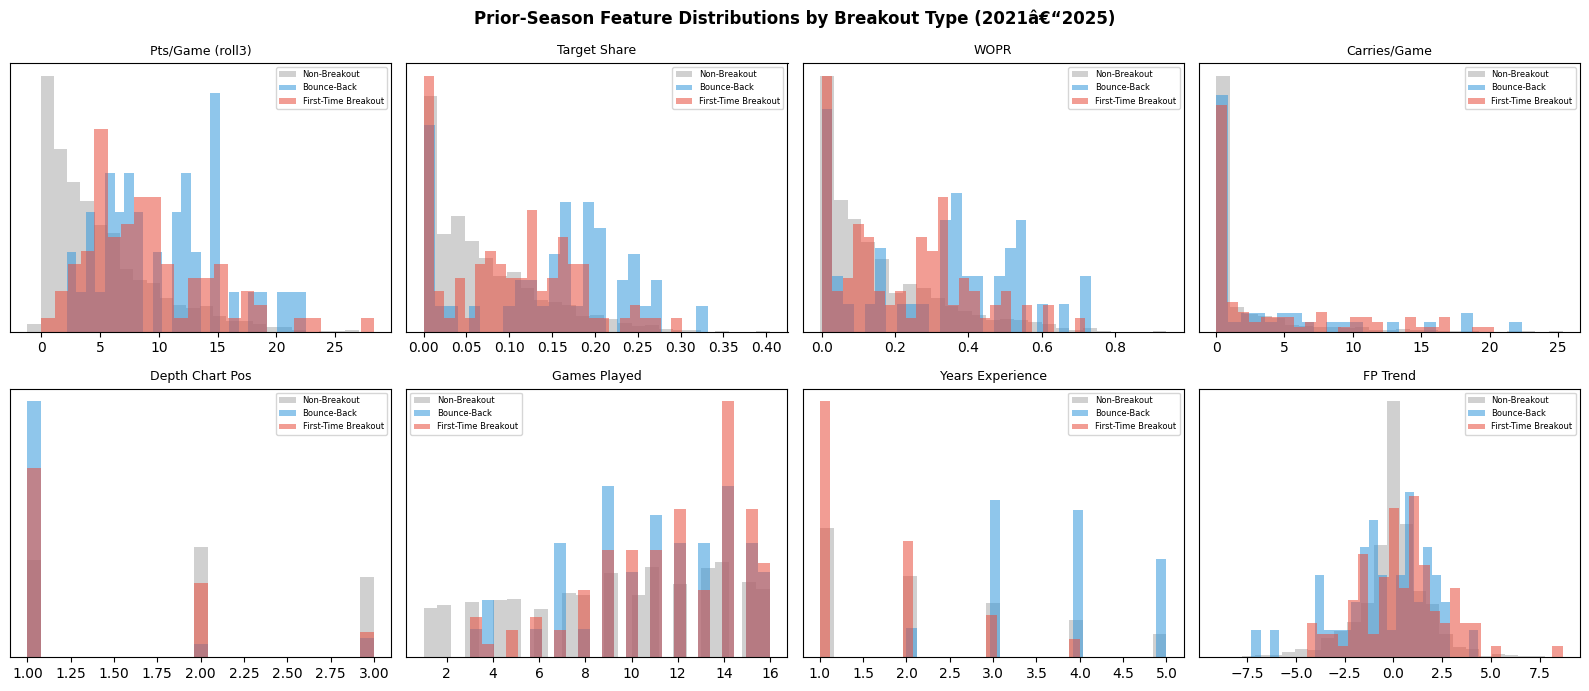

Saved: breakout_feature_distributions.png


In [4]:
compare_cols = [
    'fantasy_points_half_ppr_roll3', 'target_share_roll3', 'wopr_roll3',
    'carries_roll3', 'depth_chart_position', 'games_played', 'years_exp',
    'ffo_pts_diff_roll3', 'fantasy_points_half_ppr_trend', 'was_ever_elite'
]

# Three-way comparison: first-time breakout / bounce-back / non-breakout
groups = candidates.copy()
groups['group'] = groups['breakout_type'].map({
    'first_time': 'First-Time Breakout',
    'bounce_back': 'Bounce-Back',
    'none': 'Non-Breakout'
})
print('Average prior-season features by group:')
print(groups.groupby('group')[compare_cols].mean().round(3).T)

# Visual distributions
vis_features = [
    ('fantasy_points_half_ppr_roll3', 'Pts/Game (roll3)'),
    ('target_share_roll3', 'Target Share'),
    ('wopr_roll3', 'WOPR'),
    ('carries_roll3', 'Carries/Game'),
    ('depth_chart_position', 'Depth Chart Pos'),
    ('games_played', 'Games Played'),
    ('years_exp', 'Years Experience'),
    ('fantasy_points_half_ppr_trend', 'FP Trend'),
]
color_map = {'Non-Breakout': '#aaa', 'Bounce-Back': '#3498db', 'First-Time Breakout': '#e84d3d'}

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, (col, label) in zip(axes.flatten(), vis_features):
    for gname, color in color_map.items():
        vals = groups[groups['group'] == gname][col].dropna()
        ax.hist(vals, bins=25, alpha=0.55, color=color, label=gname, density=True)
    ax.set_title(label, fontsize=9)
    ax.legend(fontsize=6)
    ax.set_yticks([])
fig.suptitle('Prior-Season Feature Distributions by Breakout Type (2021â€“2025)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('breakout_feature_distributions.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: breakout_feature_distributions.png')

## 4. Breakout Classifier

Train on 2021â€“2023. Validate on 2024.

Target: binary breakout (either type). `was_ever_elite` feature lets the model learn the bounce-back vs first-time distinction.

=== 2024 Validation ===
ROC-AUC: 0.777

Top-N Precision (2024 validation):
  Top- 5: 1/5 hit (20%)
  Top-10: 4/10 hit (40%)
  Top-15: 7/15 hit (47%)
  Top-20: 9/20 hit (45%)
  Top-30: 10/30 hit (33%)


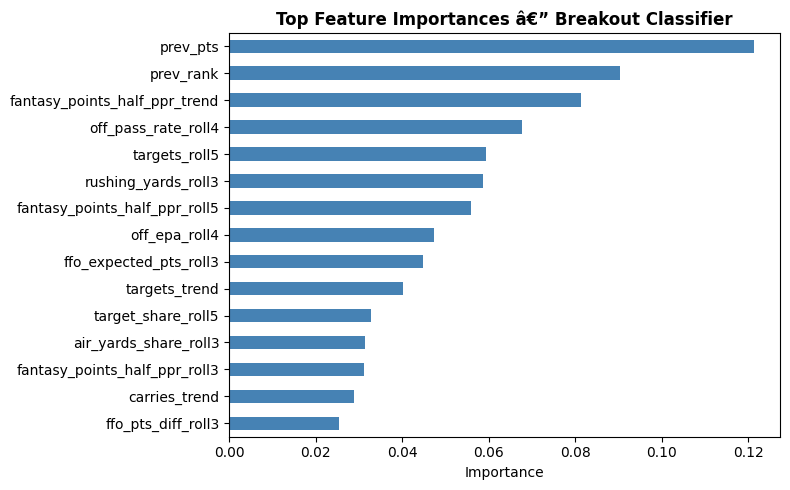

In [5]:
MODEL_FEATURES = ROLL_FEATURES + [
    'games_played', 'years_exp', 'was_ever_elite', 'prev_rank', 'prev_pts'
]

le = LabelEncoder()
candidates = candidates.copy()
candidates['pos_enc'] = le.fit_transform(candidates['position'])
MODEL_FEATURES_ENC = MODEL_FEATURES + ['pos_enc']

train = candidates[candidates['season'].between(2021, 2023)]
val   = candidates[candidates['season'] == 2024]

X_train = train[MODEL_FEATURES_ENC].fillna(0)
y_train = train['breakout'].astype(int)
X_val   = val[MODEL_FEATURES_ENC].fillna(0)
y_val   = val['breakout'].astype(int)

clf = GradientBoostingClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.04,
    subsample=0.8, min_samples_leaf=8, random_state=42
)
clf.fit(X_train, y_train)

y_prob_val = clf.predict_proba(X_val)[:, 1]

print('=== 2024 Validation ===')
print(f'ROC-AUC: {roc_auc_score(y_val, y_prob_val):.3f}')
print()

# Top-N precision: of our top-N ranked candidates, how many actually broke out?
val_ranked = val.copy()
val_ranked['prob'] = y_prob_val
val_ranked = val_ranked.sort_values('prob', ascending=False)
print('Top-N Precision (2024 validation):')
for n in [5, 10, 15, 20, 30]:
    hits = val_ranked.head(n)['breakout'].sum()
    print(f'  Top-{n:2d}: {hits}/{n} hit ({hits/n:.0%})')

# Feature importance
fi = pd.Series(clf.feature_importances_, index=MODEL_FEATURES_ENC).sort_values(ascending=True).tail(15)
fig, ax = plt.subplots(figsize=(8, 5))
fi.plot.barh(ax=ax, color='steelblue')
ax.set_title('Top Feature Importances â€” Breakout Classifier', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('breakout_feature_importance.png', dpi=130, bbox_inches='tight')
plt.show()

## 5. Predict 2025 Breakout Candidates

Apply the model to end-of-2024 data. Players already in the top tier in 2024 are excluded (they can't break out from where they already are).

In [6]:
cands_2025 = candidates[candidates['season'] == 2025].copy()
cands_2025['pos_enc'] = le.transform(cands_2025['position'])
X_2025 = cands_2025[MODEL_FEATURES_ENC].fillna(0)
cands_2025['breakout_prob'] = clf.predict_proba(X_2025)[:, 1]

print(f'2025 candidate pool: {len(cands_2025)} players')
print()

show_cols = ['player_display_name', 'breakout_type', 'prev_rank', 'prev_pts',
             'breakout_prob', 'breakout', 'season_pts', 'pos_rank']
rename_map = {
    'player_display_name': 'Player', 'breakout_type': 'Type',
    'prev_rank': '2024 Rank', 'prev_pts': '2024 Pts',
    'breakout_prob': 'Prob', 'breakout': 'Broke Out',
    'season_pts': '2025 Pts', 'pos_rank': '2025 Rank'
}

for pos in ['QB', 'RB', 'WR', 'TE']:
    sub = (cands_2025[cands_2025['position'] == pos]
           .sort_values('breakout_prob', ascending=False).head(12)
           [show_cols].rename(columns=rename_map))
    print(f'--- {pos} ---')
    print(sub.to_string(index=False))
    print()

2025 candidate pool: 331 players

--- QB ---
            Player       Type  2024 Rank  2024 Pts     Prob  Broke Out  2025 Pts  2025 Rank
    Tua Tagovailoa       none       22.0    162.96 0.789741      False    155.44         25
     Aaron Rodgers       none       15.0    248.00 0.717896      False    200.92         18
Anthony Richardson       none       25.0    136.78 0.222785      False      1.76         66
        Geno Smith       none       14.0    248.16 0.215855      False    156.42         24
         Drew Lock       none       39.0     78.60 0.211312      False     -0.40         72
       Brock Purdy       none       13.0    256.52 0.160349      False    160.60         23
    Jameis Winston       none       27.0    130.74 0.114507      False     31.74         46
        Trey Lance       none       54.0     12.20 0.099803      False     10.68         56
      Tyrod Taylor       none       52.0     13.92 0.081444      False     51.12         42
        Drake Maye first_time      

## 6. Results Assessment â€” 2025 Predictions vs Actuals

In [7]:
y_2025_true = cands_2025['breakout'].astype(int)
y_2025_prob = cands_2025['breakout_prob']

print('=== 2025 Overall Performance ===')
print(f'Actual breakouts in candidate pool: {y_2025_true.sum()}')
print(f'ROC-AUC: {roc_auc_score(y_2025_true, y_2025_prob):.3f}')
print()

# Top-N precision (most useful metric for fantasy)
ranked_2025 = cands_2025.sort_values('breakout_prob', ascending=False)
print('Top-N Precision (2025 out-of-sample):')
for n in [5, 10, 15, 20, 30]:
    hits = ranked_2025.head(n)['breakout'].sum()
    print(f'  Top-{n:2d}: {hits}/{n} correct ({hits/n:.0%})')

# Precision/recall at probability thresholds
print()
print('Threshold Sweep:')
for t in [0.20, 0.25, 0.30, 0.35, 0.40]:
    pred = (y_2025_prob >= t).astype(int)
    tp = ((pred == 1) & (y_2025_true == 1)).sum()
    fp = ((pred == 1) & (y_2025_true == 0)).sum()
    fn = ((pred == 0) & (y_2025_true == 1)).sum()
    p  = tp / (tp + fp) if (tp + fp) > 0 else 0
    r  = tp / (tp + fn) if (tp + fn) > 0 else 0
    print(f'  t={t:.2f}: {tp+fp:3d} flagged | Precision={p:.1%} | Recall={r:.1%} | Hits={tp}')

print()
print('=== Top 30 Candidates with Actual Outcomes ===')
top30 = (ranked_2025.head(30)[show_cols].rename(columns=rename_map))
print(top30.to_string(index=False))

=== 2025 Overall Performance ===
Actual breakouts in candidate pool: 30
ROC-AUC: 0.793

Top-N Precision (2025 out-of-sample):
  Top- 5: 2/5 correct (40%)
  Top-10: 3/10 correct (30%)
  Top-15: 3/15 correct (20%)
  Top-20: 4/20 correct (20%)
  Top-30: 4/30 correct (13%)

Threshold Sweep:
  t=0.20:  14 flagged | Precision=21.4% | Recall=10.0% | Hits=3
  t=0.25:   8 flagged | Precision=37.5% | Recall=10.0% | Hits=3
  t=0.30:   6 flagged | Precision=33.3% | Recall=6.7% | Hits=2
  t=0.35:   5 flagged | Precision=40.0% | Recall=6.7% | Hits=2
  t=0.40:   5 flagged | Precision=40.0% | Recall=6.7% | Hits=2

=== Top 30 Candidates with Actual Outcomes ===
               Player        Type  2024 Rank  2024 Pts     Prob  Broke Out  2025 Pts  2025 Rank
       Tua Tagovailoa        none       22.0    162.96 0.789741      False    155.44         25
        Aaron Rodgers        none       15.0    248.00 0.717896      False    200.92         18
          Cooper Kupp        none       46.0    116.50 0.41

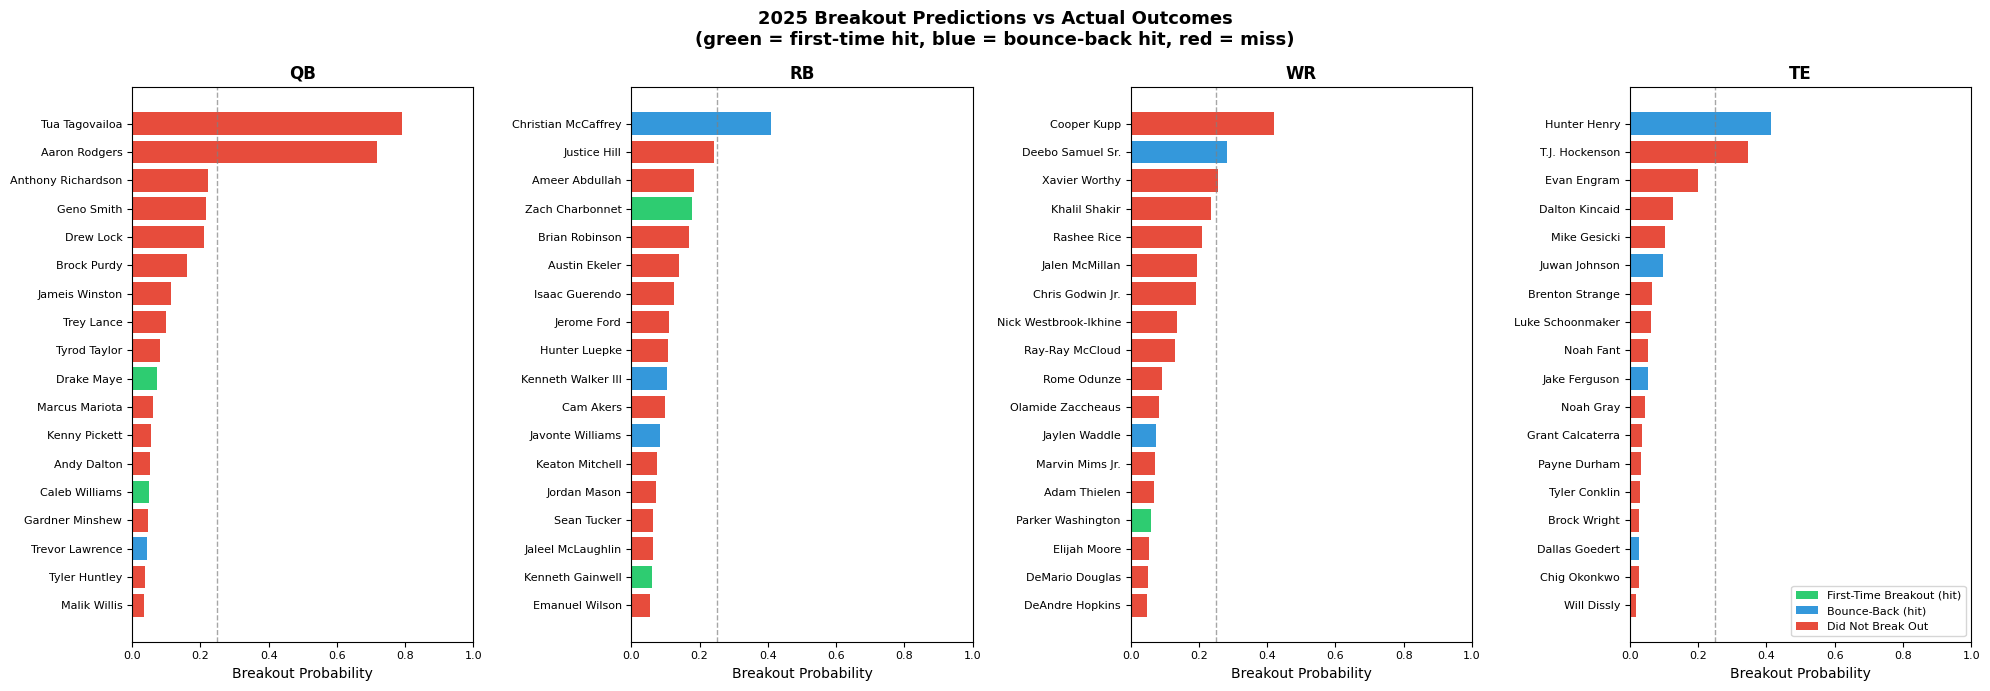

Saved: breakout_2025_results.png


In [8]:
fig, axes = plt.subplots(1, 4, figsize=(20, 7))

for ax, pos in zip(axes, ['QB', 'RB', 'WR', 'TE']):
    sub = (cands_2025[cands_2025['position'] == pos]
           .sort_values('breakout_prob', ascending=False).head(18))
    
    # Color by outcome, pattern by type
    colors = []
    for _, row in sub.iterrows():
        if row['breakout'] and row['breakout_type'] == 'first_time':
            colors.append('#2ecc71')   # green = first-time breakout hit
        elif row['breakout'] and row['breakout_type'] == 'bounce_back':
            colors.append('#3498db')   # blue = bounce-back hit
        else:
            colors.append('#e74c3c')   # red = miss
    
    ax.barh(sub['player_display_name'], sub['breakout_prob'], color=colors)
    ax.axvline(0.25, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_xlim(0, 1)
    ax.set_title(f'{pos}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Breakout Probability')
    ax.invert_yaxis()
    ax.tick_params(labelsize=8)

legend_elements = [
    Patch(facecolor='#2ecc71', label='First-Time Breakout (hit)'),
    Patch(facecolor='#3498db', label='Bounce-Back (hit)'),
    Patch(facecolor='#e74c3c', label='Did Not Break Out'),
]
axes[-1].legend(handles=legend_elements, fontsize=8, loc='lower right')

fig.suptitle('2025 Breakout Predictions vs Actual Outcomes\n'
             '(green = first-time hit, blue = bounce-back hit, red = miss)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('breakout_2025_results.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: breakout_2025_results.png')

## 7. Deep Dive â€” Correct Calls, Misses, and False Alarms

In [9]:
THRESHOLD = 0.25

actual_bk = cands_2025[cands_2025['breakout']].sort_values('breakout_prob', ascending=False)
correctly_flagged = actual_bk[actual_bk['breakout_prob'] >= THRESHOLD]
missed = actual_bk[actual_bk['breakout_prob'] < THRESHOLD].sort_values('breakout_prob', ascending=False)
false_alarms = (
    cands_2025[(cands_2025['breakout_prob'] >= THRESHOLD) & (~cands_2025['breakout'])]
    .sort_values('breakout_prob', ascending=False)
)

show = ['player_display_name', 'position', 'breakout_type', 'prev_rank', 'breakout_prob', 'season_pts', 'pos_rank']
ren  = {
    'player_display_name': 'Player', 'position': 'Pos', 'breakout_type': 'Type',
    'prev_rank': '2024 Rank', 'breakout_prob': 'Prob',
    'season_pts': '2025 Pts', 'pos_rank': '2025 Rank'
}

print(f'=== CORRECT CALLS (prob >= {THRESHOLD}) ===')
print(correctly_flagged[show].rename(columns=ren).to_string(index=False))

print(f'\n=== MISSED BREAKOUTS (prob < {THRESHOLD}) ===')
print(missed[show].rename(columns=ren).to_string(index=False))

print(f'\n=== FALSE ALARMS (prob >= {THRESHOLD}, no breakout) ===')
print(false_alarms[show].rename(columns=ren).head(12).to_string(index=False))

=== CORRECT CALLS (prob >= 0.25) ===
             Player Pos        Type  2024 Rank     Prob  2025 Pts  2025 Rank
       Hunter Henry  TE bounce_back       13.0 0.412130     140.2          6
Christian McCaffrey  RB bounce_back       78.0 0.409047     346.9          1
   Deebo Samuel Sr.  WR bounce_back       47.0 0.282360     133.1         31

=== MISSED BREAKOUTS (prob < 0.25) ===
            Player Pos        Type  2024 Rank     Prob  2025 Pts  2025 Rank
   Zach Charbonnet  RB  first_time       25.0 0.176347    160.70         24
Kenneth Walker III  RB bounce_back       27.0 0.103987    172.50         22
     Juwan Johnson  TE bounce_back       19.0 0.098370    129.80         11
  Javonte Williams  RB bounce_back       31.0 0.082482    205.90         11
     Jaylen Waddle  WR bounce_back       53.0 0.074741    157.12         19
        Drake Maye  QB  first_time       23.0 0.072494    336.18          2
 Parker Washington  WR  first_time       77.0 0.060665    155.70         21
  Kenne

## 8. Position Scorecard

In [10]:
print('=== POSITION SCORECARD ===')
print(f'{"Pos":<4} {"Actual":>7} {"Top-10 Hits":>11} {"Top-10 Prec":>12} {"Recall":>8} {"AUC":>6}')
print('-' * 52)
for pos in ['QB', 'RB', 'WR', 'TE']:
    sub = cands_2025[cands_2025['position'] == pos].sort_values('breakout_prob', ascending=False)
    n_actual = sub['breakout'].sum()
    top10    = sub.head(10)
    top10_hits = top10['breakout'].sum()
    top10_prec = top10_hits / min(10, len(top10))
    recall = top10_hits / n_actual if n_actual > 0 else 0
    try:
        auc = roc_auc_score(sub['breakout'].astype(int), sub['breakout_prob'])
    except Exception:
        auc = float('nan')
    print(f'{pos:<4} {n_actual:>7} {top10_hits:>11} {top10_prec:>12.0%} {recall:>8.0%} {auc:>6.3f}')

print()
print('Overall top-20 precision (all positions combined):')
overall_top20 = cands_2025.sort_values('breakout_prob', ascending=False).head(20)
hits20 = overall_top20['breakout'].sum()
print(f'  {hits20}/20 correct ({hits20/20:.0%})')
print()
print('Breakdown of top-20 by type:')
print(overall_top20.groupby('breakout_type').size())

=== POSITION SCORECARD ===
Pos   Actual Top-10 Hits  Top-10 Prec   Recall    AUC
----------------------------------------------------
QB         5           1          10%      20%  0.605
RB         7           3          30%      43%  0.830
WR        12           1          10%       8%  0.808
TE         6           3          30%      50%  0.848

Overall top-20 precision (all positions combined):
  4/20 correct (20%)

Breakdown of top-20 by type:
breakout_type
bounce_back     3
first_time      1
none           16
dtype: int64


## 9. Notable Results

Run cell above to see scorecard, then interpret the standout picks and misses here.

**Key model signals for breakouts:**
- Rising depth chart position (starter by end of season)
- Strong efficiency vs expectation (`ffo_pts_diff_roll3` > 0)
- Positive FP trend (recent weeks > longer stretch)
- Teammate availability (strong QB / OL availability boosts receivers)
- Years experience: 2â€“4 years is the sweet spot for first-time breakouts

**Known model limitations:**
- Data starts 2020, so players who were elite pre-2020 appear as 'first-time' breakout candidates
- Injury-induced down years are hard to distinguish from true decline without explicit injury history
- Team changes (trades, new offensive coordinators) are only partially captured via EPA/pass-rate features